In [1]:
import os
import copy
import logging
import h5py as h5
import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib

import matplotlib.cm as cm



# ------------------------------
# Plot style
# ------------------------------
matplotlib.rcParams.update({
    'font.size': 20,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.bottom': True,
    'ytick.left': True,
    
    'text.usetex': True,  # Enable LaTeX rendering
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],  # LaTeX default font
})

Zsun = 0.02  
threshold = 1.00 #threshold for MRR, mB > threshold * mA
# ------------------------------
# Load COMPAS data
# ------------------------------

with h5.File("processed_yields_COMPAS.h5", "r") as f:
    z_vals_compas = f["z_values"][()]
    Y_compas      = f["yields"][()]

    # LVK defined M1
    m1_compas     = np.maximum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    m2_compas     = np.minimum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    
    MRR_bh_compas = (f["event_properties/mass_2"][()] > threshold *
                     f["event_properties/mass_1"][()])

    Z_compas      = f["event_properties/metallicity"][()]  
    logZrel_compas  = np.log10(Z_compas / Zsun)

    # Just ensure we are grabbing M1 and M2 ZAMS. 
    zams1_compas  = np.maximum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    zams2_compas  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    
    delay_time_compas = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_compas_binary_assumption = f["event_properties/mass_1"][()]
    m2_compas_binary_assumption = f["event_properties/mass_2"][()]

# ------------------------------
# Load SEVN data
# ------------------------------

# with h5.File("processed_yields_SEVN.h5", "r") as f:
with h5.File("../data/yields/sevn_updated.hdf5", "r") as f:
    z_vals_sevn = f["z_values"][()]
    Y_sevn      = f["yields"][()]

    m1_sevn     = np.maximum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    m2_sevn     = np.minimum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    MRR_bh_sevn = (f["event_properties/mass_2"][()] > threshold *
                   f["event_properties/mass_1"][()])

    Z_sevn      = f["event_properties/metallicity"][()]
    logZrel_sevn  = np.log10(Z_sevn / Zsun)

    zams1_sevn  = np.maximum(f["event_properties/zams_mass_1"][()],
                              f["event_properties/zams_mass_2"][()])
    zams2_sevn  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])

    delay_time_sevn = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_sevn_binary_assumption = f["event_properties/mass_1"][()]
    m2_sevn_binary_assumption = f["event_properties/mass_2"][()]


In [5]:
base_dir = "../data/dRdM1_variations/"

compas_configs = [
    {"tag": "fiducial",  "label": r"Fiducial",          "color": "k",  "ls": "-"},
    {"tag": "alpha0_5",  "label": r"$\alpha_{\rm CE}=0.5$",  "color": "C0", "ls": "-"},
    {"tag": "alpha2",    "label": r"$\alpha_{\rm CE}=2$",    "color": "C1", "ls": "-"},
    {"tag": "alpha10",   "label": r"$\alpha_{\rm CE}=10$",   "color": "C2", "ls": "-"},
    {"tag": "rapid",     "label": r"Rapid SN",               "color": "C3", "ls": "-"},
    {"tag": "ccsn30kms", "label": r"$\sigma_{\rm BH}=30\,{\rm km/s}$",   "color": "C4", "ls": "-"},
    {"tag": "ccsn100kms","label": r"$\sigma_{\rm BH}=100\,{\rm km/s}$",  "color": "C5", "ls": "-"},
    {"tag": "MT_0_5",    "label": r"$\beta=0.5$",       "color": "C6", "ls": "-"},
    {"tag": "MT_0_25",   "label": r"$\beta=0.25$",      "color": "C10", "ls": "-"},
    {"tag": "WR_0_1",    "label": r"$f_{\rm WR}=0.1$",       "color": "C8", "ls": "-"},
    {"tag": "WR_5",      "label": r"$f_{\rm WR}=5$",         "color": "C9", "ls": "-"},
]

# separate out fiducial and variants
fid_cfg     = next(c for c in compas_configs if c["tag"] == "fiducial")
variant_cfgs = [c for c in compas_configs if c["tag"] != "fiducial"]

In [6]:
def load_compas_run(tag):
    fname = os.path.join(base_dir, f"dRdM1_mrr_decomp_compas_{tag}.npz")
    data = np.load(fname, allow_pickle=True)
    m1_centers = data["m1_centers"]
    mrr_vals   = data["mrr_vals"]   # should be shape (2, N): [MRR, non-MRR]
    return m1_centers, mrr_vals[0], mrr_vals[1]

# Fig 4

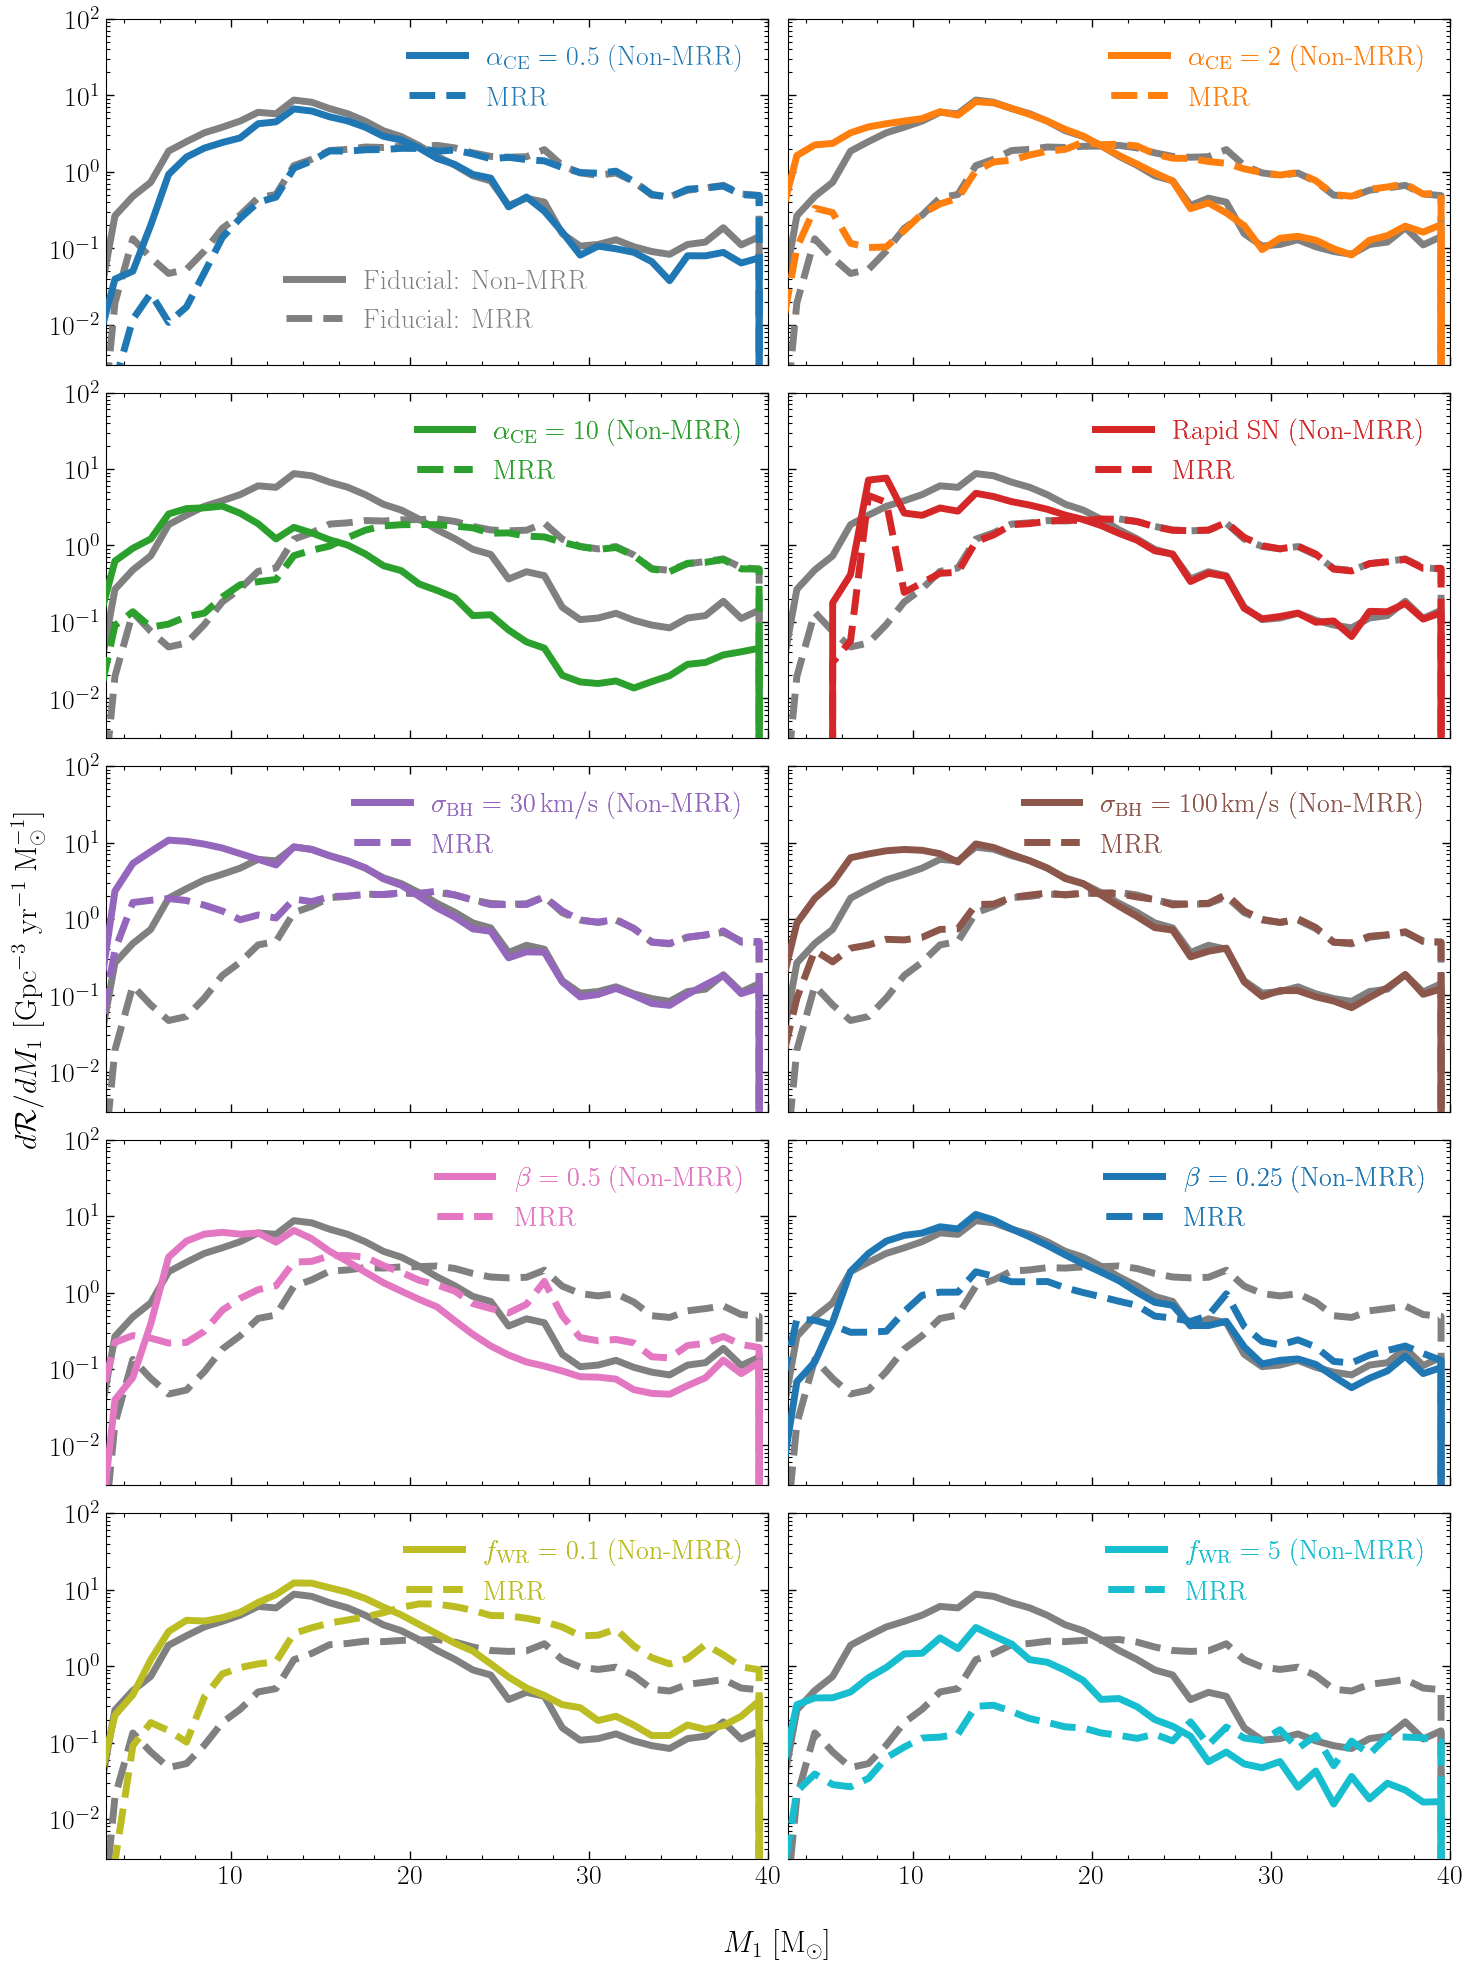

In [7]:
# Load fiducial
m1_fid, nonmrr_fid, mrr_fid = load_compas_run(fid_cfg["tag"])


fig, axes = plt.subplots(
    nrows=5, ncols=2,
    figsize=(16, 20),
    sharex=True, sharey=True,
)

fig.set_constrained_layout_pads(hspace=0.0, wspace=0.0)
axes_flat = axes.flatten()


## Plot loop

for i, (ax, cfg) in enumerate(zip(axes_flat, variant_cfgs)):
    m1_var, nonmrr_var, mrr_var = load_compas_run(cfg["tag"])



    # Fiducial overlay (gray)
    if i == 0:
        ax.plot(m1_fid, nonmrr_fid, color="gray", ls="-",  lw=5, alpha=1, label="Fiducial: Non-MRR")
        ax.plot(m1_fid, mrr_fid,    color="gray", ls="--", lw=5.0, alpha=1, label="Fiducial: MRR")
    else:
        ax.plot(m1_fid, nonmrr_fid, color="gray", ls="-",  lw=5, alpha=1)
        ax.plot(m1_fid, mrr_fid,    color="gray", ls="--", lw=5.0, alpha=1)

        # Variant — colored, non-MRR=solid, MRR=dashed
    ax.plot(m1_var, nonmrr_var, color=cfg["color"], ls="-",  lw=5, alpha=1,
            label=cfg["label"] +" (Non-MRR)", zorder=9)
    ax.plot(m1_var, mrr_var,    color=cfg["color"], ls="--", lw=5.0, alpha=1,
            zorder=10,label="MRR")


    ax.set_yscale("log")

    
    ax.set_xlim(3, 40)
    ax.set_ylim(3e-3, 1e2)

    
    handles, labels = ax.get_legend_handles_labels()

    var_h, var_l = [], []
    fid_h, fid_l = [], []

    for h, l in zip(handles, labels):
        if l.startswith("Fiducial:"):
            fid_h.append(h); fid_l.append(l)
        else:
            var_h.append(h); var_l.append(l)

    leg_var = ax.legend(
        var_h, var_l,
        frameon=False,
        fontsize=20,
        loc="upper right",
        labelcolor="linecolor"
    )
    ax.add_artist(leg_var) 

    if i == 0:
        # Legend for fiducial
        ax.legend(
            fid_h, fid_l,
            frameon=False,
            fontsize=20,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),  
            labelcolor="linecolor"
        )
    else:
        # no legend elsewhere
        pass
        

# Turn off unused axes if variant_cfgs < 10
for ax in axes_flat[len(variant_cfgs):]:
    ax.axis("off")

# Shared labels
fig.supxlabel(r"$M_1$ [M$_\odot$]", fontsize=22)
fig.supylabel(r"$d\mathcal{R}/dM_1$ [Gpc$^{-3}$ yr$^{-1}$ M$_\odot^{-1}$]", fontsize=22)


plt.minorticks_on()


plt.subplots_adjust(
    wspace=0.03,
    hspace=0.08,
    left=0.08,
    right=0.92,
    bottom=0.06,
    top=0.98,
)

plt.savefig("../plots/dRdM1_compas_variations_beta.pdf", bbox_inches="tight", pad_inches=0.04)
plt.show()

# Fig11

In [8]:
def load_compas_run(tag):
    fname = os.path.join(base_dir, f"dRdMchirp_mrr_decomp_compas_{tag}.npz")
    data = np.load(fname, allow_pickle=True)
    m1_centers = data["m1_centers"]
    mrr_vals   = data["mrr_vals"]   # should be shape (2, N): [MRR, non-MRR]
    return m1_centers, mrr_vals[0], mrr_vals[1]

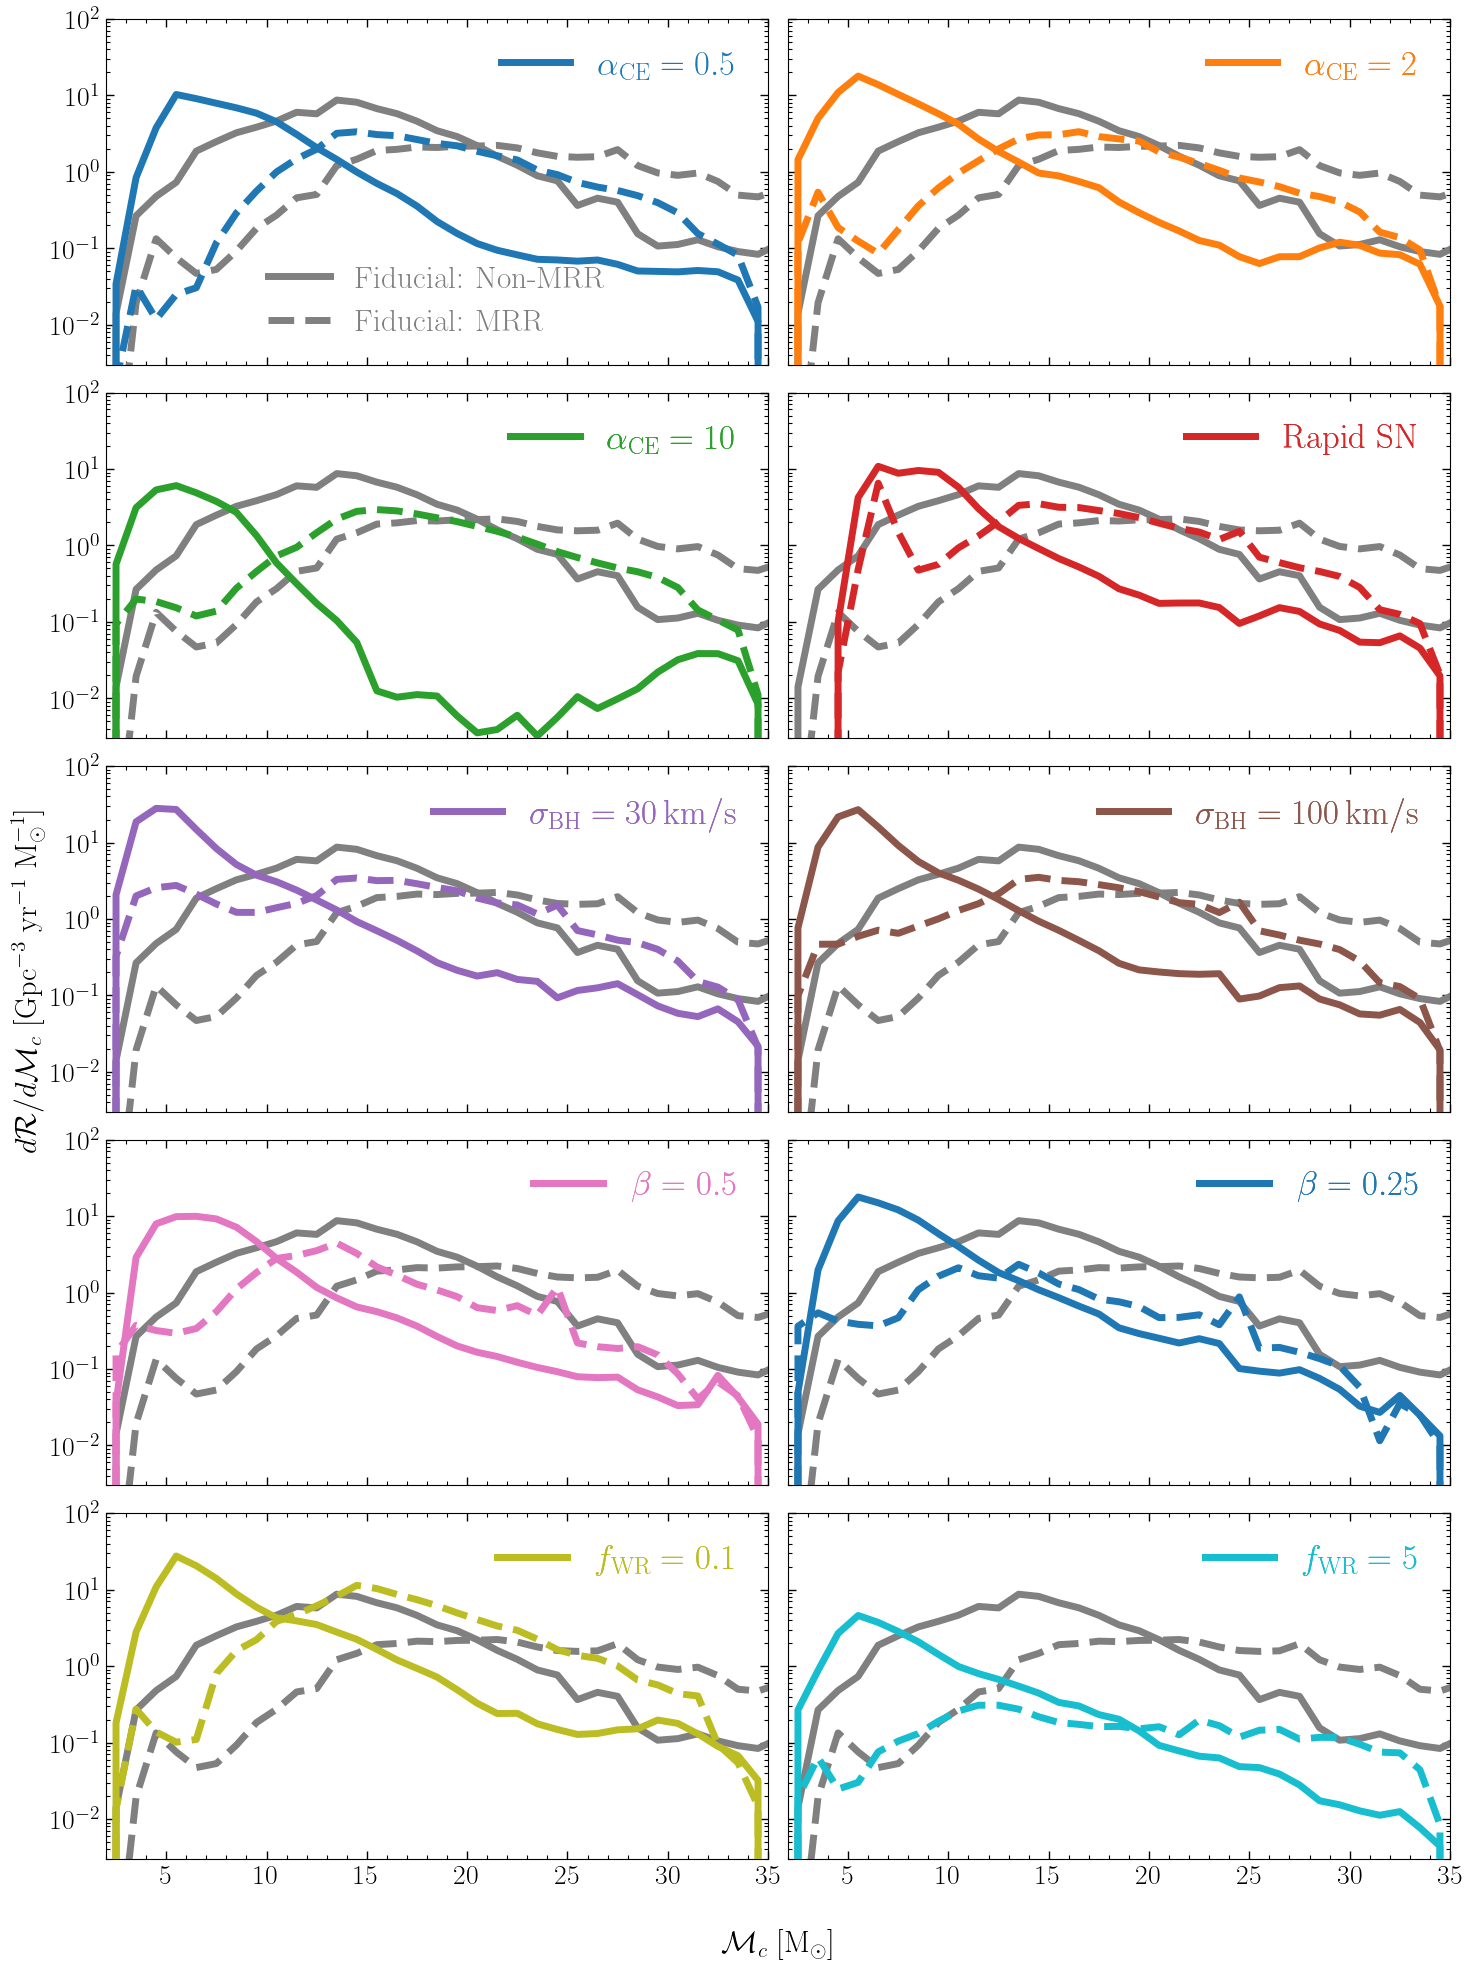

In [10]:
fig, axes = plt.subplots(
    nrows=5, ncols=2,
    figsize=(16, 20),
    sharex=True, sharey=True,
)


fig.set_constrained_layout_pads(hspace=0.0, wspace=0.0)
axes_flat = axes.flatten()

# Plot loop

for i, (ax, cfg) in enumerate(zip(axes_flat, variant_cfgs)):
    m1_var, nonmrr_var, mrr_var = load_compas_run(cfg["tag"])



    # Fiducial overlay (gray)
    if i == 0:
        ax.plot(m1_fid, nonmrr_fid, color="gray", ls="-",  lw=5, alpha=1, label="Fiducial: Non-MRR")
        ax.plot(m1_fid, mrr_fid,    color="gray", ls="--", lw=5.0, alpha=1, label="Fiducial: MRR")
    else:
        ax.plot(m1_fid, nonmrr_fid, color="gray", ls="-",  lw=5, alpha=1)
        ax.plot(m1_fid, mrr_fid,    color="gray", ls="--", lw=5.0, alpha=1)

        # Variant — colored, non-MRR=solid, MRR=dashed
    ax.plot(m1_var, nonmrr_var, color=cfg["color"], ls="-",  lw=5, alpha=1,
            label=cfg["label"], zorder=9)
    ax.plot(m1_var, mrr_var,    color=cfg["color"], ls="--", lw=5.0, alpha=1,
            zorder=10)


    ax.set_yscale("log")
    ax.set_xlim(2, 35)
    ax.set_ylim(3e-3, 1e2)


    
    # variant legends
    handles, labels = ax.get_legend_handles_labels()

    var_h, var_l = [], []
    fid_h, fid_l = [], []

    for h, l in zip(handles, labels):
        if l.startswith("Fiducial:"):
            fid_h.append(h); fid_l.append(l)
        else:
            var_h.append(h); var_l.append(l)

    leg_var = ax.legend(
        var_h, var_l,
        frameon=False,
        fontsize=25,
        loc="upper right",
        labelcolor="linecolor"
    )
    ax.add_artist(leg_var)  

    if i == 0:
        # legend for fiducial
        ax.legend(
            fid_h, fid_l,
            frameon=False,
            fontsize=22.5,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.00),
            labelcolor="linecolor"
        )
    else:
        # no legend elsewhere
        pass
        

# Turn off unused axes if variant_cfgs < 10
for ax in axes_flat[len(variant_cfgs):]:
    ax.axis("off")

# Shared labels
fig.supxlabel(r"$\mathcal{M}_c$ [M$_\odot$]", fontsize=22)
fig.supylabel(r"$d\mathcal{R}/d\mathcal{M}_c$ [Gpc$^{-3}$ yr$^{-1}$ M$_\odot^{-1}$]", fontsize=22)


plt.minorticks_on()


plt.subplots_adjust(
    wspace=0.03,
    hspace=0.08,
    left=0.08,
    right=0.92,
    bottom=0.06,
    top=0.98,
)

#plt.savefig("../plots/dRdMchirp_compas_variations_beta.pdf", bbox_inches="tight", pad_inches=0.04)
plt.show()

# Fig 15

In [11]:
def load_compas_yields(filepath):
    with h5.File(filepath, "r") as f:
        z_vals = f["z_values"][()]
        Y      = f["yields"][()]

        m1 = np.maximum(f["event_properties/mass_1"][()],
                        f["event_properties/mass_2"][()])
        m2 = np.minimum(f["event_properties/mass_1"][()],
                        f["event_properties/mass_2"][()])

        # Binary definition (no max/min)
        m1_bin = f["event_properties/mass_1"][()]
        m2_bin = f["event_properties/mass_2"][()]

    return z_vals, Y, m1, m2, m1_bin, m2_bin

In [12]:
base_dir = "../data/yields"

file_map = {
    # "fiducial":  "compas-fiducial.hdf5",
    "alpha0_5":  "compas-alpha-0_5.hdf5",
    "alpha2":    "compas-alpha-2_0.hdf5",
    "alpha10":   "compas-alpha-10.hdf5",
    "rapid":     "compas-rapid.hdf5",
    "ccsn30kms":    "compas-ccsn30kms.hdf5",
    "ccsn100kms":   "compas-ccsn100kms.hdf5",
    "MT_0_5":    "compas-MT-0_5.hdf5",
    "MT_0_25":   "compas-MT-0_25.hdf5",
    "WR_0_1":    "compas-WR-0_1.hdf5",
    "WR_5":      "compas-WR-5.hdf5",
}

In [13]:
m1_bins = np.arange(3, 50, 1)
m2_bins = np.arange(3, 50, 1)

m1_centers = 0.5 * (m1_bins[:-1] + m1_bins[1:])
m2_centers = 0.5 * (m2_bins[:-1] + m2_bins[1:])

label_map = {cfg["tag"]: cfg["label"] for cfg in compas_configs}

alpha0_5
alpha2
alpha10
rapid
ccsn30kms
ccsn100kms
MT_0_5
MT_0_25
WR_0_1
WR_5


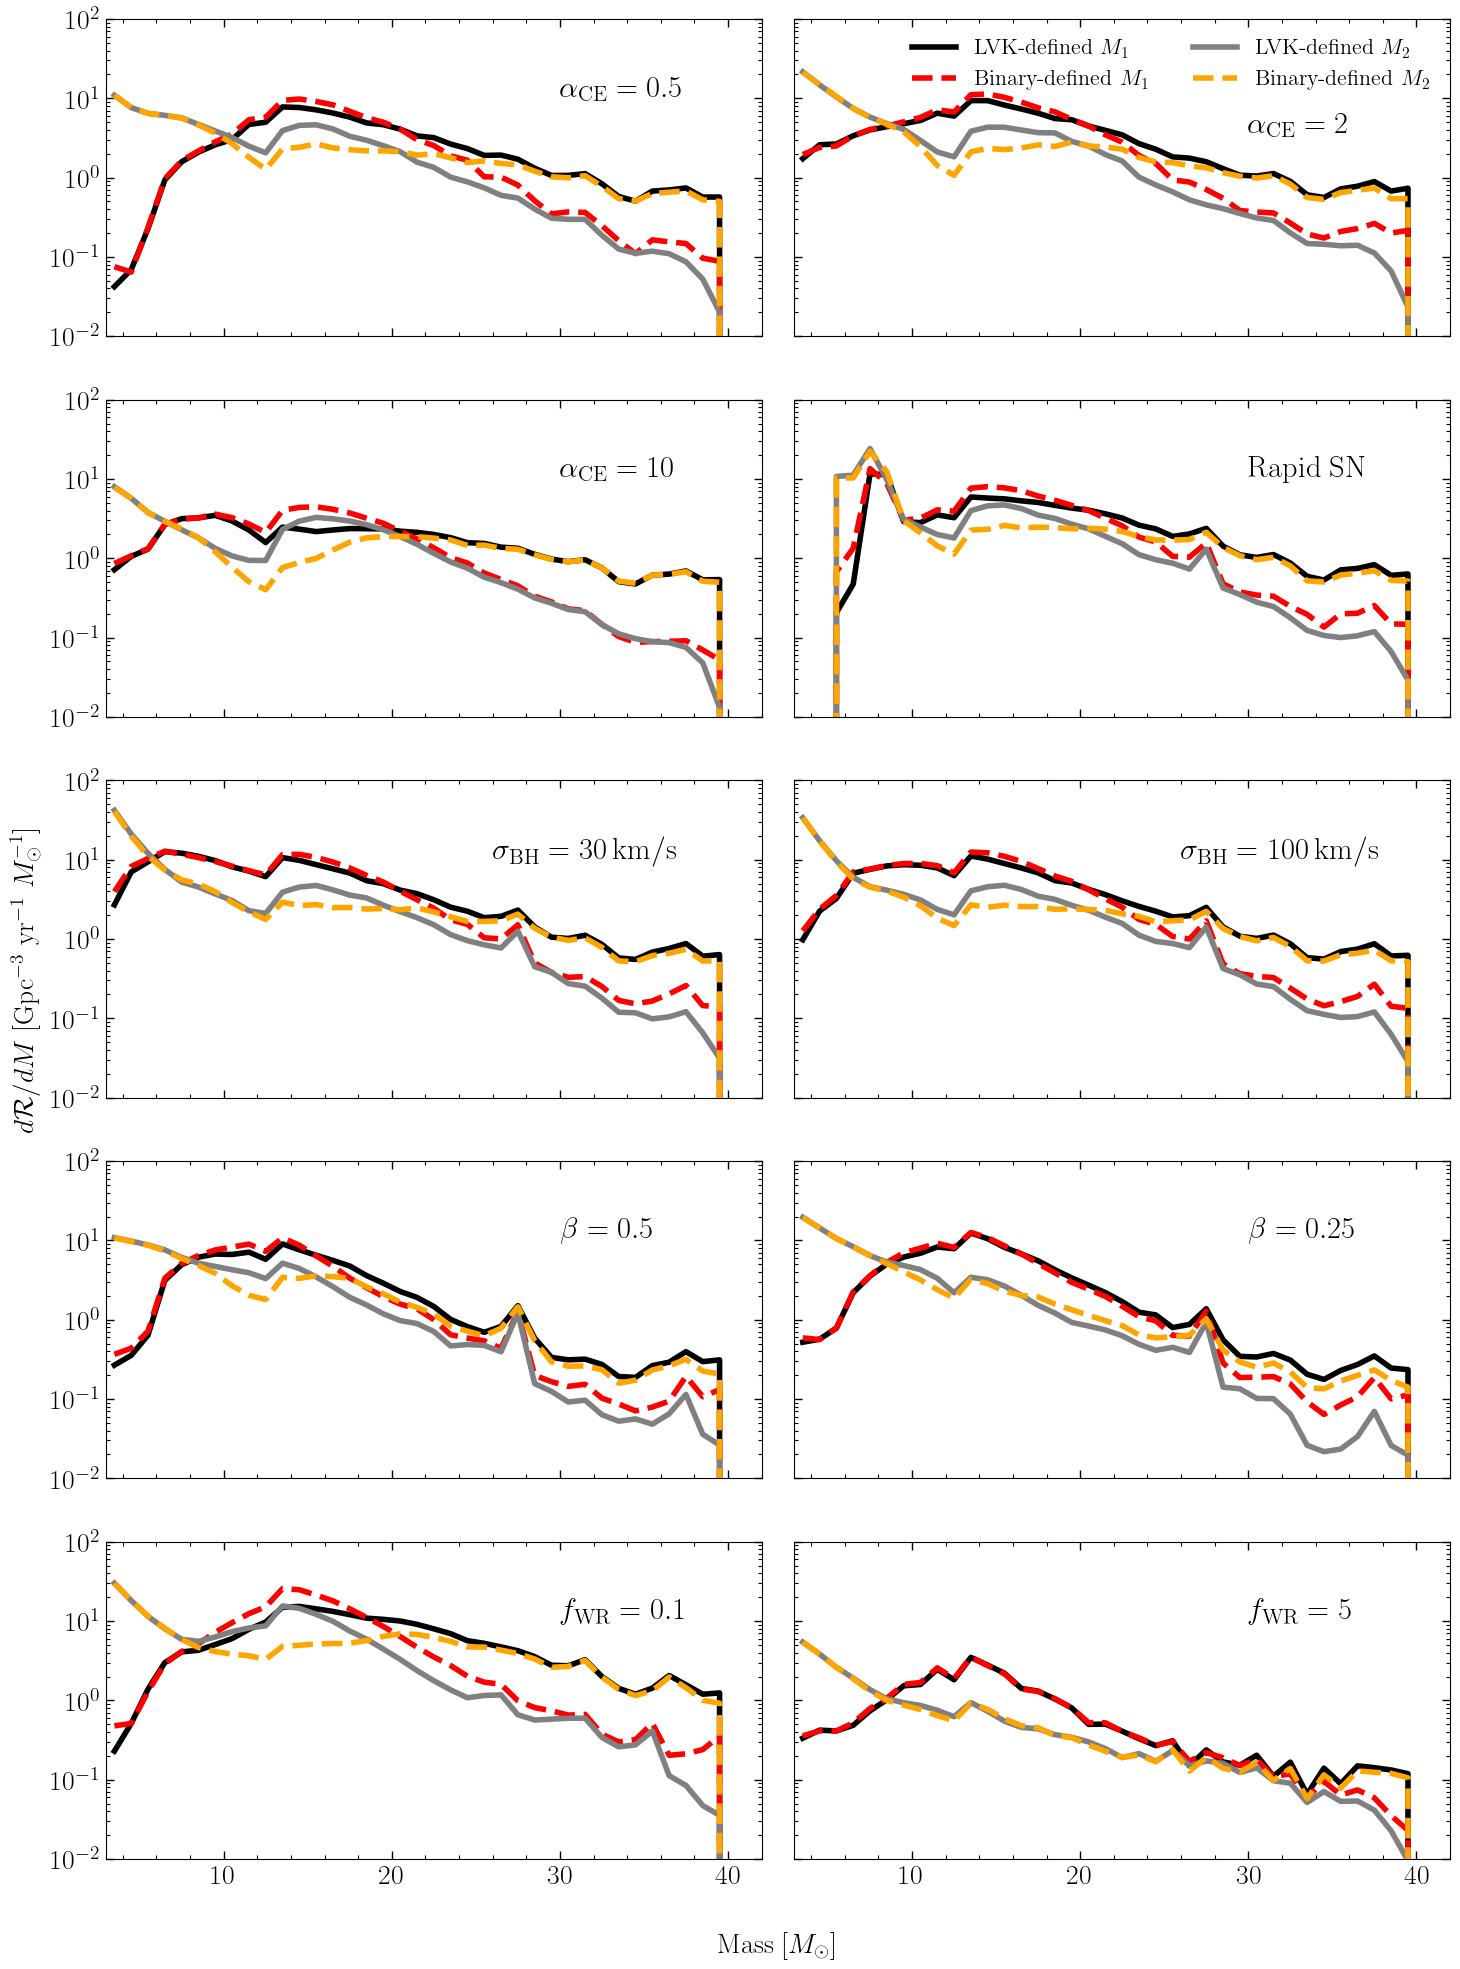

In [14]:
ncols = 2
nrows = int(np.ceil(len(file_map) / ncols))

fig, axes = plt.subplots(
    nrows=5, ncols=2,
    figsize=(16, 20),
    sharex=True, sharey=True,
)


fig.set_constrained_layout_pads(hspace=0.0, wspace=0.0) # can remove. 

axes = axes.flatten()


for ax, (tag, fname) in zip(axes, file_map.items()):

    filepath = os.path.join(base_dir, fname)

    z_vals, Y, m1, m2, m1_bin, m2_bin = load_compas_yields(filepath)

    # pick redshift index 
    z_idx = 2   # z~0.2

    weights = Y[z_idx]

    # --- M1 ---
    dRdM1 = np.histogram(m1, bins=m1_bins, weights=weights)[0]
    dRdM1_bin = np.histogram(m1_bin, bins=m1_bins, weights=weights)[0]

    # --- M2 ---
    dRdM2 = np.histogram(m2, bins=m2_bins, weights=weights)[0]
    dRdM2_bin = np.histogram(m2_bin, bins=m2_bins, weights=weights)[0]

    # normalize by bin width 
    dm1 = m1_centers[1] - m1_centers[0]
    dm2 = m2_centers[1] - m2_centers[0]

    dRdM1 /= dm1
    dRdM1_bin /= dm1
    dRdM2 /= dm2
    dRdM2_bin /= dm2

    # plot both on same panel
    ax.plot(m1_centers, dRdM1, color="k", lw=4, label="LVK-defined $M_1$")
    ax.plot(m1_centers, dRdM1_bin, color="r", lw=4, ls="--", label="Binary-defined $M_1$")

    ax.plot(m2_centers, dRdM2, color="gray", lw=4, label="LVK-defined $M_2$")
    ax.plot(m2_centers, dRdM2_bin, color="orange", lw=4, ls="--", label="Binary-defined $M_2$")

    # styling
    ax.set_yscale("log")
    ax.set_xlim(3, 42)
    ax.set_ylim(1e-2, 1e2)
    
    
    ax.minorticks_on()

    label = label_map.get(tag, tag)
    

    print(tag)
    if tag == "alpha2":
        ax.text(
            30, 7,
            label,
            fontsize=22,
            va='top',
            ha='left',
        )
        
    elif 'km' in label:
        
        ax.text(
            26, 20,
            label,
            fontsize=22,
            va='top',
            ha='left',
        )
    else:
        ax.text(
            30, 20,
            label,
            fontsize=22,
            va='top',
            ha='left',
        )

axes[1].legend(ncol=2,loc="upper right", fontsize=16,frameon=False)

# clean extra axes
for ax in axes[len(file_map):]:
    ax.axis("off")


fig.supxlabel(r"Mass [$M_\odot$]", fontsize=20)
fig.supylabel(r"$d\mathcal{R}/dM$ [Gpc$^{-3}$ yr$^{-1}$ $M_\odot^{-1}$]", fontsize=20)

plt.subplots_adjust(
    wspace=0.03,
    hspace=0.08,
    left=0.08,
    right=0.92,
    bottom=0.06,
    top=0.98,
)

plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.savefig("../plots/final-compas-massquerade-variations.pdf")
plt.show()